  # II. DESCRIPTIVE ANALYSIS

## 1. Introduction

The objective of this analysis is to identify meaningful patterns, relationships,
and variations within the hospitalized heart-failure patient population.

The analysis focuses on patient characteristics, clinical severity, cardiac
function, laboratory measurements, complications, medications, and
hospitalization outcomes. Rather than only presenting summary statistics,
specific analytical questions will be used to investigate important patterns
within the data.

Each question will be supported by an appropriate analysis and visualization,
followed by an interpretation of the findings. The findings will also help
identify areas that can be explored further through prescriptive and predictive
analysis.

### 2. Import Libraries

The analysis uses Pandas and NumPy for data manipulation and numerical
analysis, while Matplotlib and Seaborn are used to create clear and
informative visualizations.

In [33]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import pathlib
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


### 3. Load Master Patient Dataset

The cleaned patient-level datasets were combined during the data preparation
stage to create the master patient table. This table contains one row per
patient and serves as the common analytical dataset for the descriptive,
prescriptive, and predictive stages.

The master table is loaded from the cleaned-data folder so that this notebook
uses the same validated analytical population without repeating the earlier
cleaning and merging process.

In [34]:
# Project and cleaned-data paths
DATA_PATH = Path(
    r"C:\Users\arjai\Documents\Shraddha Job Search\Data Science\Python\Hackathon Sept 2026\Python_Hackathon_Sep_2026"
)

CLEANED_PATH = DATA_PATH / "cleaned_data"

# Load the validated master patient dataset
MASTER_PATH = CLEANED_PATH / "Team11_PyInsights_cleaned_data.csv"

patient_master = pd.read_csv(MASTER_PATH)

print("Master patient dataset loaded successfully.")
print(f"Rows: {patient_master.shape[0]:,}")
print(f"Columns: {patient_master.shape[1]:,}")

Master patient dataset loaded successfully.
Rows: 2,008
Columns: 198


In [35]:
# Check the column names before calculating anything. A missing column means
# the wrong version of Team11_PyInsights_cleaned_data.csv may have been loaded.
missing_columns = [column for column, _ in severity_fields.values() if column not in df.columns]
if missing_columns:
    raise KeyError(f"Severity columns missing from Team11_PyInsights_cleaned_data.csv: {missing_columns}")

In [3]:
# Create the dataframe used for descriptive analysis

df = patient_master.copy()

print("Descriptive analysis dataframe created.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Descriptive analysis dataframe created.
Rows: 2,008
Columns: 198


### 4. Initial Dataset Validation

Before beginning the descriptive questions, the master dataset is checked
to confirm that the expected patient-level structure has been preserved.

The checks focus on the dataset size, patient identifier uniqueness,
duplicate records, data types, and missing values. This provides confidence
that the analysis is being performed on the intended analytical population
and helps identify variables that may require consideration when answering
individual questions.

In [4]:
# Dataset structure

print("Dataset Shape:", df.shape)

print("\nNumber of Patients:", df["inpatient_number"].nunique())

print("Duplicate Patient IDs:",
      df["inpatient_number"].duplicated().sum())

print("Duplicate Rows:",
      df.duplicated().sum())

Dataset Shape: (2008, 198)

Number of Patients: 2008
Duplicate Patient IDs: 0
Duplicate Rows: 0


In [5]:
# Data type summary

print("Data Type Summary:")
display(df.dtypes.value_counts())

Data Type Summary:


float64    149
int64       30
object      14
bool         5
Name: count, dtype: int64

In [6]:
# Missing-value overview

missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing_summary = missing_summary[missing_summary > 0]

print("Columns with missing values:", len(missing_summary))

display(missing_summary.head(30))

Columns with missing values: 123


respiratory_support                             1966
time_of_death_days_from_admission               1964
homocysteine                                    1862
apolipoprotein_a                                1832
lipoprotein                                     1832
apolipoprotein_b                                1832
tricuspid_valve_return_pressure                 1826
erythrocyte_sedimentation_rate                  1701
ea                                              1615
myoglobin                                       1610
serum_magnesium                                 1601
inorganic_phosphorus                            1601
mitral_valve_ams                                1458
glutamic_oxaliplatin                            1416
lvef                                            1373
tricuspid_valve_return_velocity                 1218
time_to_emergency_department_within_6_months    1111
readmission_time_days_from_admission            1107
high_sensitivity_protein                      

## Question 1 — How many patients are in each NYHA class and Killip grade?

**Why these fields?** NYHA class describes limits on physical activity from heart failure symptoms. Killip grade records clinical signs of cardiac severity. Together, their *separate* distributions describe this patient group at admission. They measure different things, so matching class numbers would not mean the two assessments agree.

**How we answer it:** Check that both fields contain the grades documented in the team's cleaned table, count patients in each grade, and calculate each grade's share of all patients. Show missing records separately so the percentages have a clear denominator. Then plot the two distributions. A later question can examine how the two grades overlap within the same patients.

The [American Heart Association explains NYHA classes](https://www.heart.org/en/health-topics/heart-failure/what-is-heart-failure/classes-of-heart-failure); the dataset's data dictionary defines the recorded Killip grades.


In [7]:
# Step 1: Identify the two cleaned columns and the grades we expect in each.
severity_fields = {
    "NYHA class": ("nyha_cardiac_function_classification", [2, 3, 4]),
    "Killip grade": ("killip_grade", [1, 2, 3, 4]),
}

# Check the column names before calculating anything. A missing column means
# the wrong version of patient_master.csv may have been loaded.
missing_columns = [column for column, _ in severity_fields.values() if column not in df.columns]
if missing_columns:
    raise KeyError(f"Severity columns missing from patient_master.csv: {missing_columns}")

severity_tables = {}
for name, (column, possible_grades) in severity_fields.items():
    # Convert to numbers, but stop if a non-empty value is not a documented grade.
    numeric = pd.to_numeric(df[column], errors="coerce")
    invalid = df[column].notna() & (numeric.isna() | ~numeric.isin(possible_grades))
    if invalid.any():
        raise ValueError(f"{name} has {int(invalid.sum())} unrecognized grade(s); review the source.")

    # Include grades with zero patients to make the distributions easy to compare.
    counts = numeric.value_counts().reindex(possible_grades, fill_value=0).astype(int)
    severity_tables[name] = pd.DataFrame({
        "Grade": possible_grades,
        "Patients": counts.to_numpy(),
        "Percent of all patients": (counts.to_numpy() / len(df) * 100).round(1),
    })

    # The denominator is the full master table; show missing grades explicitly.
    print(f"\n{name}: {int(numeric.notna().sum()):,} recorded; {int(numeric.isna().sum()):,} missing")
    display(severity_tables[name])



NYHA class: 2,008 recorded; 0 missing


,Grade,Patients,Percent of all patients
0,2,353,17.6
1,3,1039,51.7
2,4,616,30.7



Killip grade: 2,008 recorded; 0 missing


,Grade,Patients,Percent of all patients
0,1,527,26.2
1,2,1029,51.2
2,3,392,19.5
3,4,60,3.0


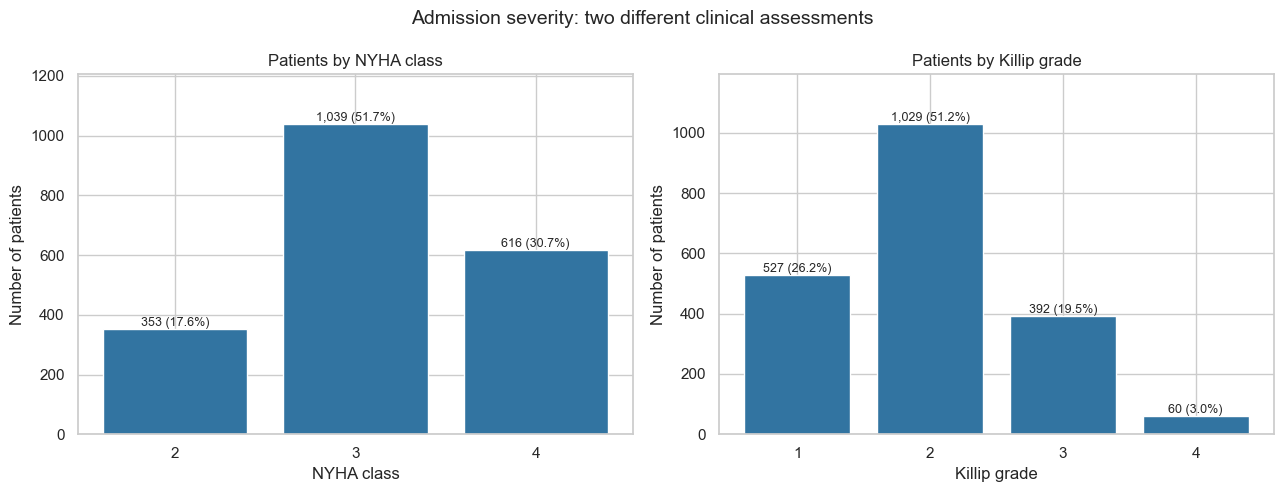

Most common NYHA class: 3 — 1,039 patients (51.7% of all patients).
Most common Killip grade: 2 — 1,029 patients (51.2% of all patients).


In [8]:
# Step 2: Show one bar chart per clinical assessment, with both counts and percentages.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, summary) in zip(axes, severity_tables.items()):
    bars = ax.bar(summary["Grade"].astype(str), summary["Patients"], color="#3274a1")
    ax.set(title=f"Patients by {name}", xlabel=name, ylabel="Number of patients")
    ax.set_ylim(0, max(1, summary["Patients"].max()) * 1.16)
    for bar, count, percent in zip(bars, summary["Patients"], summary["Percent of all patients"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{count:,} ({percent:.1f}%)", ha="center", va="bottom", fontsize=9)

fig.suptitle("Admission severity: two different clinical assessments", fontsize=14)
plt.tight_layout()
plt.show()

# State a finding using the real counts after the dataset has been loaded.
for name, summary in severity_tables.items():
    largest = summary.loc[summary["Patients"].idxmax()]
    print(f"Most common {name}: {int(largest['Grade'])} — "
          f"{int(largest['Patients']):,} patients ({largest['Percent of all patients']:.1f}% of all patients).")


### What Question 1 tells us

The tables and charts establish how common each recorded severity grade is in the full patient group. Use the displayed percentages and missing counts when describing the result. A large count for one grade tells us that grade was common *in this dataset*; it does not explain what caused the patient's condition.


## Question 2 — How do NYHA classes and Killip grades overlap in the same patients?

**Why this question?** Question 1 counts each grade separately. A table of patients who have *both* recorded scores shows which combinations occurred together, including whether patients within one NYHA class received several different Killip grades. This helps the team decide what comparisons to explore later.

**How we answer it:** Keep only patients with both recorded grades. Cross-tabulate their NYHA class and Killip grade, then divide each NYHA row by its own total. A heatmap displays the counts and within-class percentages. We also report how many patients were left out for missing grades.

**Interpretation limit:** NYHA and Killip assess different aspects of illness. Their numerical grade labels do not mean the same thing, so a diagonal on the chart is **not** an agreement rate. Formal correlation and outcome comparisons belong in the separate prescriptive notebook.


In [9]:
# Step 1: Use the same patient-level table as Question 1.
nyha_column = "nyha_cardiac_function_classification"
killip_column = "killip_grade"
severity_pairs = df[[nyha_column, killip_column]].dropna().copy()

# Count every observed NYHA/Killip combination; keep the expected grade order.
pair_counts = pd.crosstab(
    severity_pairs[nyha_column].astype(int),
    severity_pairs[killip_column].astype(int),
).reindex(index=[2, 3, 4], columns=[1, 2, 3, 4], fill_value=0)
pair_counts.index.name = "NYHA class"
pair_counts.columns.name = "Killip grade"

# Each percentage is within one NYHA class (each nonempty row sums to 100%).
row_totals = pair_counts.sum(axis=1)
pair_percent = pair_counts.div(row_totals.replace(0, np.nan), axis=0).mul(100).round(1)

print(f"Patients with both grades: {len(severity_pairs):,} of {len(df):,}")
print(f"Patients missing one or both grades: {len(df) - len(severity_pairs):,}")
print("\nNumber of patients in each combination:")
display(pair_counts)
print("Percent within each NYHA class (rows):")
display(pair_percent)


Patients with both grades: 2,008 of 2,008
Patients missing one or both grades: 0

Number of patients in each combination:


Killip grade,1,2,3,4
NYHA class,,,,
2,136,151,66,0
3,304,543,190,2
4,87,335,136,58


Percent within each NYHA class (rows):


Killip grade,1,2,3,4
NYHA class,,,,
2,38.5,42.8,18.7,0.0
3,29.3,52.3,18.3,0.2
4,14.1,54.4,22.1,9.4


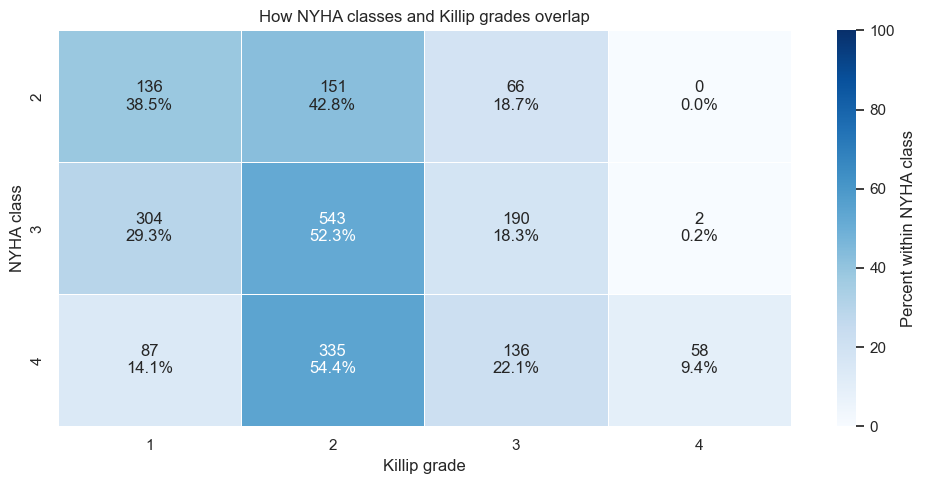

Most frequent combination: NYHA 3 and Killip 2 (543 patients, 27.0% of patients with both grades).


In [10]:
# Step 2: Label each heatmap cell with both the patient count and the row percentage.
labels = np.array([
    [f"{pair_counts.loc[nyha, killip]:,}\n{pair_percent.loc[nyha, killip]:.1f}%"
     if row_totals.loc[nyha] else "No patients"
     for killip in pair_counts.columns]
    for nyha in pair_counts.index
])

plt.figure(figsize=(10, 5))
sns.heatmap(
    pair_percent.fillna(0), annot=labels, fmt="", cmap="Blues", vmin=0, vmax=100,
    cbar_kws={"label": "Percent within NYHA class"}, linewidths=0.5,
)
plt.title("How NYHA classes and Killip grades overlap")
plt.xlabel("Killip grade")
plt.ylabel("NYHA class")
plt.tight_layout()
plt.show()

# Give the reader a factual result without claiming that matching numbers mean agreement.
largest_pair = pair_counts.stack().idxmax()
largest_count = int(pair_counts.loc[largest_pair])
print(f"Most frequent combination: NYHA {largest_pair[0]} and Killip {largest_pair[1]} "
      f"({largest_count:,} patients, {largest_count / len(severity_pairs):.1%} of patients with both grades).")


### What Question 2 tells us

Read *across a row* to see how Killip grades are distributed among patients in one NYHA class. The percentage denominator changes from row to row and is printed in the table above. The chart describes overlap in this patient group; it cannot tell us that one score causes the other or that the two assessments measure the same condition.


<p style="font-family: Cambria; font-size: 18px;"><b>Q3. What does cardiac function (LVEF) and type of heart failure look like across the cohort?</b></p>

**Why:** LVEF and HF type describe the structural/functional picture of the heart — the next layer after admission severity.

**What:** `lvef`, `type_of_heart_failure`.

**How:** Distribution + explicit missingness callout, since LVEF is only recorded for a minority of patients.

**Counter-Argument:** With ~68% missing, is this worth showing? Yes — *how much* and *whether it's random* is itself a finding, not a reason to skip the column.

**What We Expect:** A left-skewed distribution (more reduced-EF patients, since this is a hospitalized HF cohort).

**Evidence:** LVEF recorded for only 635 of 2,008 patients (31.6%; 68.4% missing). Among those recorded: mean 50.7%, median 51%, IQR 41–61%, range 5–82%. Contrary to what we expected, the distribution is roughly symmetric around a near-normal EF (≥50% is generally considered preserved), not skewed toward reduced EF. Separately, `type_of_heart_failure` is not an EF-based phenotype (HFrEF/HFmrEF/HFpEF) but a laterality classification: Both-sided 73.7% (n=1,480), Left-sided 23.8% (n=477), Right-sided 2.5% (n=51).

**Why It Matters:** Two corrections for the team going forward: (1) any later LVEF-based comparison must state "n=635 (31.6% of cohort)" explicitly, and the near-normal median EF means this cohort isn't dominated by classic reduced-EF heart failure the way we assumed; (2) `type_of_heart_failure` should not be used as an HFrEF/HFpEF stand-in in any Category 3 question — it measures a different clinical dimension entirely (left vs. right vs. biventricular involvement), so a genuine EF-phenotype split would have to be derived from `lvef` itself, on the smaller 635-patient subset.

**Follow-Up:** Does LVEF category relate to comorbidity burden or outcomes?

LVEF missing: 68.4% (n=635 of 2008 have a recorded value)


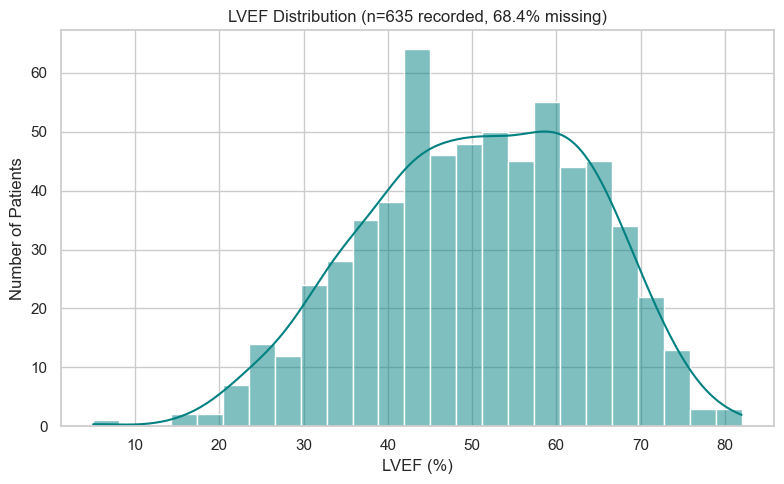

count    635.000000
mean      50.682992
std       13.221701
min        5.000000
25%       41.000000
50%       51.000000
75%       61.000000
max       82.000000
Name: lvef, dtype: float64

Type of heart failure:
type_of_heart_failure
Both     1480
Left      477
Right      51
Name: count, dtype: int64
type_of_heart_failure
Both     73.7
Left     23.8
Right     2.5
Name: proportion, dtype: float64


In [11]:
# Q3: LVEF distribution + missingness, and HF type distribution
lvef_missing_pct = df['lvef'].isna().mean() * 100
lvef_n = df['lvef'].notna().sum()

print(f"LVEF missing: {lvef_missing_pct:.1f}% (n={lvef_n} of {len(df)} have a recorded value)")

plt.figure(figsize=(8, 5))
sns.histplot(df['lvef'].dropna(), bins=25, kde=True, color='teal')
plt.title(f'LVEF Distribution (n={lvef_n} recorded, {lvef_missing_pct:.1f}% missing)')
plt.xlabel('LVEF (%)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(df['lvef'].describe())

print("\nType of heart failure:")
print(df['type_of_heart_failure'].value_counts(dropna=False))
print(df['type_of_heart_failure'].value_counts(normalize=True, dropna=False).round(3) * 100)

<p style="font-family: Cambria; font-size: 18px;"><b>Q4. What is the comorbidity burden in this cohort, and which comorbidities are most prevalent?</b></p>

**Why:** CCI score and individual comorbidity flags describe chronic disease burden — independent of acute admission severity (Q1).

**What:** `cci_score`, plus flags: cerebrovascular_disease, dementia, chronic_obstructive_pulmonary_disease, connective_tissue_disease, peptic_ulcer_disease, diabetes, moderate_to_severe_chronic_kidney_disease, hemiplegia, leukemia, malignant_lymphoma, solid_tumor, liver_disease, aids, acute_renal_failure.

**How:** Histogram of CCI; ranked bar chart of prevalence (mean of each 0/1 flag).

**Counter-Argument:** Some flags (e.g. `moderate_to_severe_chronic_kidney_disease`, `liver_disease`, `cci_score`) are Float, not Integer, in the cleaned data — a NaN-preserving cast from cleaning, not a data error; worth noting so it isn't mistaken for one.

**What We Expect:** Diabetes and CKD likely dominate, given known HF comorbidity patterns.

**Evidence:** CCI score: mean 1.86, median 2, IQR 1–2 (n=2,003 of 2,008 — 5 patients missing a CCI value). As expected, chronic kidney disease (23.6%) and diabetes (23.2%) are the two most prevalent comorbidities, essentially tied, followed by COPD (11.6%) and cerebrovascular disease (7.5%). Leukemia and malignant lymphoma are effectively absent (0.0%). Note: `acute_renal_failure` (0.3%) was excluded from this comorbidity ranking on review — it's an acute in-hospital event, not a chronic comorbidity like the other 13, so grouping it here would have misrepresented what the question measures.

**Why It Matters:** CKD and diabetes are the two comorbidities Category 4 should prioritize as candidate risk features — they're not just present, they're roughly 2x more prevalent than the next tier (COPD). The near-zero prevalence of leukemia/lymphoma means those two columns are unlikely to be useful predictors anywhere downstream and can probably be dropped from later feature lists rather than carried forward out of habit.

**Follow-Up:** Does comorbidity burden correlate with 6-month readmission?

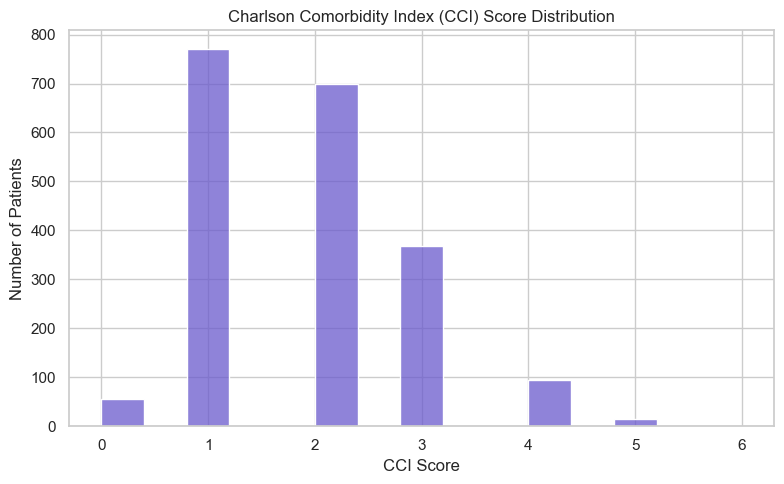

count    2003.000000
mean        1.861707
std         0.961469
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         6.000000
Name: cci_score, dtype: float64


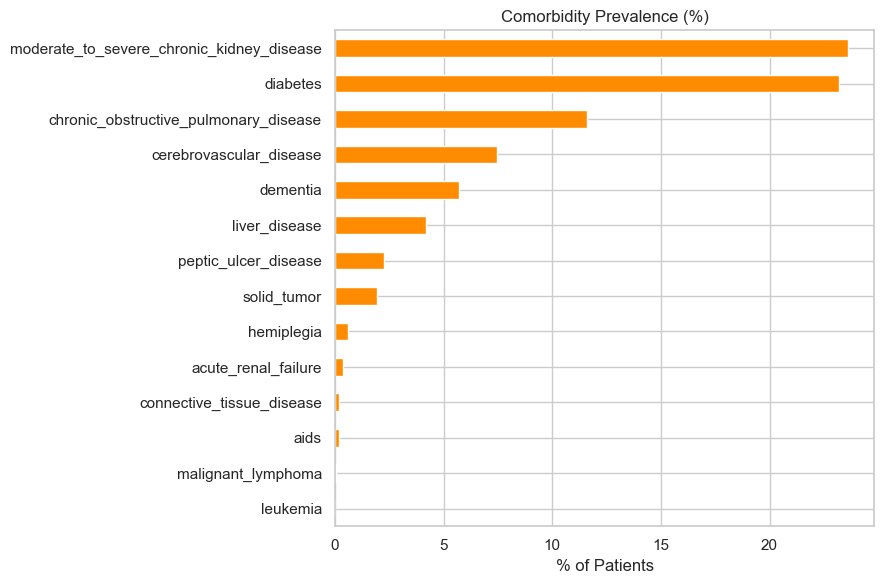

moderate_to_severe_chronic_kidney_disease    23.6
diabetes                                     23.2
chronic_obstructive_pulmonary_disease        11.6
cerebrovascular_disease                       7.5
dementia                                      5.7
liver_disease                                 4.2
peptic_ulcer_disease                          2.2
solid_tumor                                   1.9
hemiplegia                                    0.6
acute_renal_failure                           0.3
connective_tissue_disease                     0.2
aids                                          0.2
malignant_lymphoma                            0.0
leukemia                                      0.0
dtype: float64


In [12]:
# Q4: CCI distribution + top comorbidities
plt.figure(figsize=(8, 5))
sns.histplot(df['cci_score'].dropna(), bins=15, color='slateblue')
plt.title('Charlson Comorbidity Index (CCI) Score Distribution')
plt.xlabel('CCI Score')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(df['cci_score'].describe())

comorbidity_cols = [
    'cerebrovascular_disease', 'dementia', 'chronic_obstructive_pulmonary_disease',
    'connective_tissue_disease', 'peptic_ulcer_disease', 'diabetes',
    'moderate_to_severe_chronic_kidney_disease', 'hemiplegia', 'leukemia',
    'malignant_lymphoma', 'solid_tumor', 'liver_disease', 'aids', 'acute_renal_failure'
]

comorbidity_prevalence = (df[comorbidity_cols].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
comorbidity_prevalence.plot(kind='barh', color='darkorange')
plt.title('Comorbidity Prevalence (%)')
plt.xlabel('% of Patients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(comorbidity_prevalence.round(1))

<p style="font-family: Cambria; font-size: 18px;"><b>Q5. What are the cohort's baseline death and readmission rates at 28 days, 3 months, and 6 months?</b></p>

**Why:** This is the anchor every Category 3/4 subgroup finding gets compared against — a subgroup rate means nothing without the overall rate stated first.

**What:** `death_within_28_days`, `re_admission_within_28_days`, `death_within_3_months`, `re_admission_within_3_months`, `death_within_6_months`, `re_admission_within_6_months`, `outcome_during_hospitalization`.

**How:** One summary table of rates — a table, not a chart, since the point is precise, quotable numbers.

**Counter-Argument:** Six near-identical columns could look like padding — they're one construct (time-windowed views of the same two outcomes), not six separate questions.

**What We Expect:** Rates should rise monotonically from 28 days → 6 months (more time = more events).

**Evidence:** Both death and readmission rates rise monotonically with time window, as expected: death 1.8% (28d) → 2.1% (3mo) → 2.8% (6mo); readmission 7.0% (28d) → 24.8% (3mo) → 38.5% (6mo). In-hospital outcome: 94.1% discharged alive, 5.3% (n=107) discharged against medical order, 0.5% (n=11) died in-hospital. Notably, in-hospital mortality (0.5%) is far lower than 28-day mortality (1.8%) — most 28-day deaths occur post-discharge, not during the admission itself.

**Why It Matters:** Readmission, not death, is this cohort's dominant risk — by 6 months, over 1 in 3 patients are back in the hospital, versus under 3% who have died. This should steer where the team spends its Category 3/4 effort: readmission-focused questions have far more signal (773 events) to work with than mortality-focused ones (57 events at 6 months) will ever have. Separately, the 107 patients discharged against medical order is a large enough, well-defined group to support Dhivya's reserve question on outcomes for that specific subgroup — worth promoting that into the active Category 3 list rather than leaving it as a reserve idea.

**Follow-Up:** Which subgroups deviate most from these baseline rates?



In [13]:
# Q5: Baseline outcome rates
outcome_cols = [
    'death_within_28_days', 're_admission_within_28_days',
    'death_within_3_months', 're_admission_within_3_months',
    'death_within_6_months', 're_admission_within_6_months'
]

outcome_rates = (df[outcome_cols].mean() * 100).round(1)
outcome_summary = pd.DataFrame({
    'Rate (%)': outcome_rates,
    'Count': df[outcome_cols].sum().astype(int)
})
print(outcome_summary)

print("\nIn-hospital outcome:")
print(df['outcome_during_hospitalization'].value_counts())
print(df['outcome_during_hospitalization'].value_counts(normalize=True).round(3) * 100)

                              Rate (%)  Count
death_within_28_days               1.8     37
re_admission_within_28_days        7.0    140
death_within_3_months              2.1     42
re_admission_within_3_months      24.8    498
death_within_6_months              2.8     57
re_admission_within_6_months      38.5    773

In-hospital outcome:
outcome_during_hospitalization
Alive                      1890
Discharge Against Order     107
Dead                         11
Name: count, dtype: int64
outcome_during_hospitalization
Alive                      94.1
Discharge Against Order     5.3
Dead                        0.5
Name: proportion, dtype: float64


### Q6.What does the distribution of Brain Natriuretic Peptide (BNP) tell us about the cardiac biomarker profile of the cohort, and how does BNP vary across heart-failure severity groups?

#### Why this question?
BNP is a clinically relevant biomarker associated with cardiac stress and
heart-failure severity. Unlike categorical measures such as NYHA or Killip
classification, BNP provides a continuous measure of cardiac burden.

Examining its distribution helps us understand the typical BNP level, the
degree of variability, the presence of extreme values, and whether the
biomarker is available consistently across the cohort.

#### What are we examining?
- BNP missingness and data availability
- Central tendency using mean and median
- Spread using standard deviation and percentiles
- Distribution shape and skewness
- BNP differences across NYHA class, Killip grade, and heart-failure type

#### How?
We will calculate descriptive statistics for BNP and compare its mean and
median across clinically defined heart-failure groups.

Missing BNP values are retained as missing rather than imputed because the
absence of a laboratory measurement may indicate that the test was not
ordered or recorded. Imputing these values could create artificial clinical
measurements.

#### Expected outcome
We expect BNP to show substantial variation across patients and potentially
a right-skewed distribution because very high values may occur in patients
with greater cardiac stress.

The results will help us determine whether BNP is useful for subsequent
prescriptive and predictive analysis, particularly when identifying
higher-risk patient groups or selecting clinically meaningful predictors.

In [15]:
# Use the validated master dataset already loaded above
df_master = patient_master.copy()

bnp_col = "brain_natriuretic_peptide"

print("BNP analysis dataset loaded successfully.")
print(f"Total patients: {len(df_master):,}")
print(f"BNP column available: {bnp_col in df_master.columns}")

BNP analysis dataset loaded successfully.
Total patients: 2,008
BNP column available: True


In [16]:
# BNP availability
bnp = df_master[bnp_col]

total_patients = len(df_master)
valid_bnp = bnp.notna().sum()
missing_bnp = bnp.isna().sum()

print("==============================================================")
print("BNP DATA AVAILABILITY")
print("==============================================================")
print(f"Total patients       : {total_patients:,}")
print(f"BNP recorded         : {valid_bnp:,} ({valid_bnp / total_patients * 100:.2f}%)")
print(f"BNP missing          : {missing_bnp:,} ({missing_bnp / total_patients * 100:.2f}%)")

# Descriptive statistics for available BNP values
bnp_stats = bnp.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

print("\n==============================================================")
print("BNP DESCRIPTIVE STATISTICS")
print("==============================================================")
print(f"Mean                 : {bnp_stats['mean']:.2f} pg/mL")
print(f"Median               : {bnp_stats['50%']:.2f} pg/mL")
print(f"Standard deviation   : {bnp_stats['std']:.2f} pg/mL")
print(f"Minimum              : {bnp_stats['min']:.2f} pg/mL")
print(f"25th percentile      : {bnp_stats['25%']:.2f} pg/mL")
print(f"75th percentile      : {bnp_stats['75%']:.2f} pg/mL")
print(f"95th percentile      : {bnp_stats['95%']:.2f} pg/mL")
print(f"99th percentile      : {bnp_stats['99%']:.2f} pg/mL")
print(f"Maximum              : {bnp_stats['max']:.2f} pg/mL")

print(f"\nSkewness              : {bnp.skew():.2f}")

BNP DATA AVAILABILITY
Total patients       : 2,008
BNP recorded         : 1,973 (98.26%)
BNP missing          : 35 (1.74%)

BNP DESCRIPTIVE STATISTICS
Mean                 : 1280.44 pg/mL
Median               : 753.03 pg/mL
Standard deviation   : 1354.16 pg/mL
Minimum              : 2.69 pg/mL
25th percentile      : 303.94 pg/mL
75th percentile      : 1738.52 pg/mL
95th percentile      : 5000.00 pg/mL
99th percentile      : 5000.00 pg/mL
Maximum              : 5000.00 pg/mL

Skewness              : 1.49


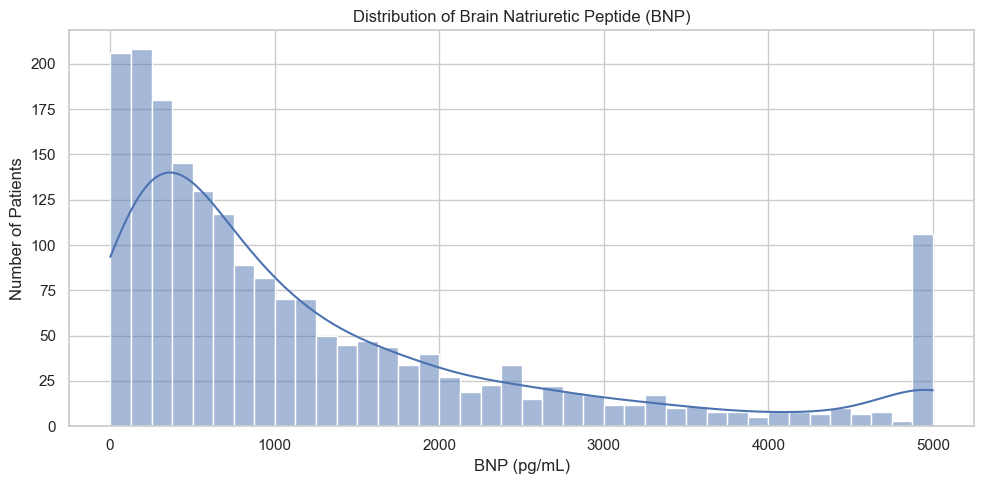

In [17]:
# Distribution of BNP
plt.figure(figsize=(10, 5))

sns.histplot(
    bnp.dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Brain Natriuretic Peptide (BNP)")
plt.xlabel("BNP (pg/mL)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

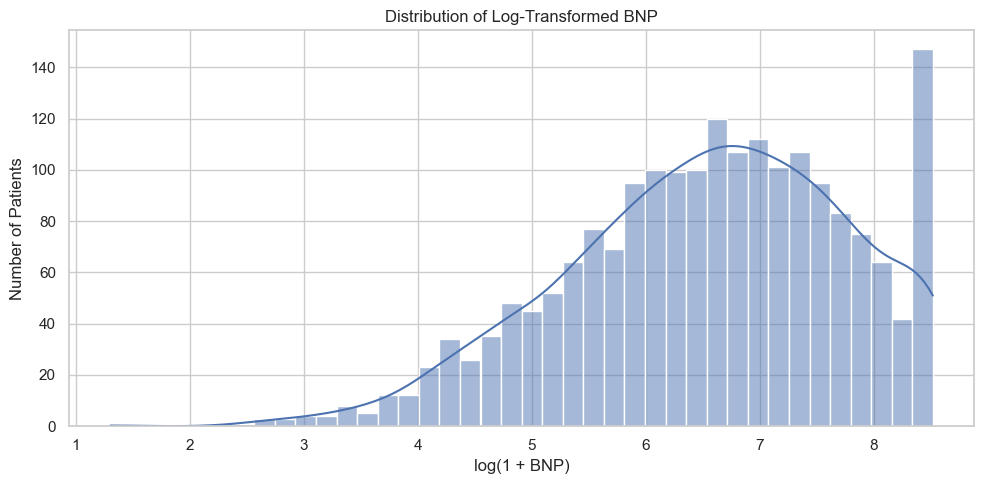

In [18]:
# Log-transformed BNP distribution for highly skewed values
bnp_positive = bnp[bnp > 0].dropna()

plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(bnp_positive),
    bins=40,
    kde=True
)

plt.title("Distribution of Log-Transformed BNP")
plt.xlabel("log(1 + BNP)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

The raw BNP distribution is examined first because it preserves the clinical units. A log-transformed view is used only to visualize a highly skewed distribution more clearly and does not replace the original BNP values.

In [19]:
# Clinical variables to compare with BNP
severity_columns = [
    "nyha_cardiac_function_classification",
    "killip_grade",
    "type_of_heart_failure"
]

for col in severity_columns:

    if col not in df_master.columns:
        print(f"\n{col}: column not found.")
        continue

    print("\n" + "=" * 70)
    print(f"BNP BY {col.upper()}")
    print("=" * 70)

    profile = (
        df_master
        .groupby(col, dropna=False)[bnp_col]
        .agg(
            Patient_Count="count",
            Mean_BNP="mean",
            Median_BNP="median",
            Std_BNP="std"
        )
        .round(2)
    )

    print(profile)


BNP BY NYHA_CARDIAC_FUNCTION_CLASSIFICATION
                                      Patient_Count  Mean_BNP  Median_BNP  \
nyha_cardiac_function_classification                                        
2                                               348    966.32      529.82   
3                                              1017   1173.83      693.87   
4                                               608   1638.55     1130.34   

                                      Std_BNP  
nyha_cardiac_function_classification           
2                                     1135.26  
3                                     1283.55  
4                                     1502.99  

BNP BY KILLIP_GRADE
              Patient_Count  Mean_BNP  Median_BNP  Std_BNP
killip_grade                                              
1                       520    990.30      571.19  1149.99
2                      1010   1386.31      802.74  1422.95
3                       385   1291.17      809.98  1307.61
4            

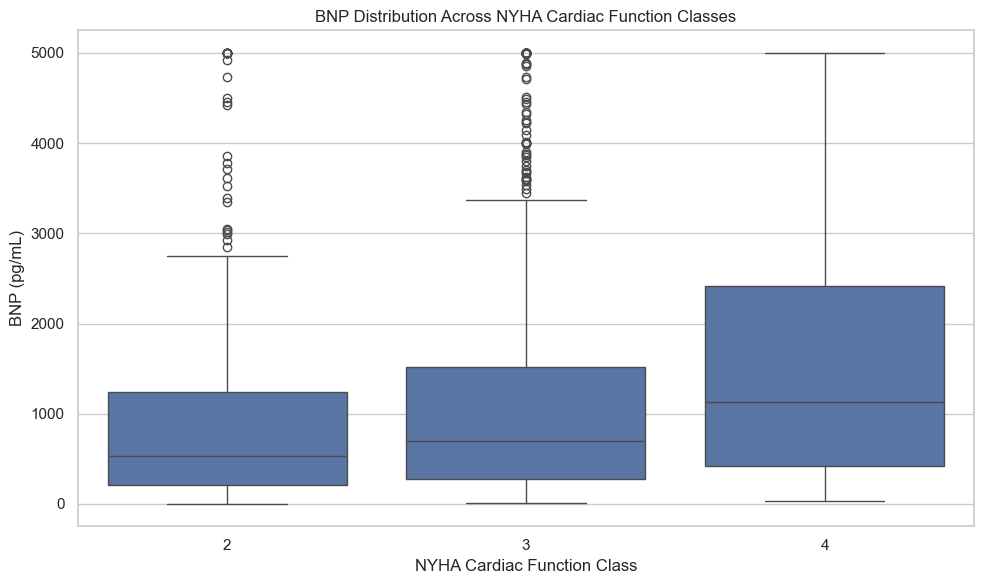

In [20]:
nyha_col = "nyha_cardiac_function_classification"

if nyha_col in df_master.columns:

    plot_data = df_master[
        [nyha_col, bnp_col]
    ].dropna()

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=plot_data,
        x=nyha_col,
        y=bnp_col
    )

    plt.title("BNP Distribution Across NYHA Cardiac Function Classes")
    plt.xlabel("NYHA Cardiac Function Class")
    plt.ylabel("BNP (pg/mL)")
    plt.tight_layout()
    plt.show()

<p style="font-family: Cambria; font-size: 18px;"><b>Q6. What does the distribution of Brain Natriuretic Peptide (BNP) tell us about the cardiac biomarker profile of the cohort, and how does BNP vary across heart-failure severity groups?</b></p>

#### Findings

BNP is **well represented** in the cohort, with **98.26%** of patients (1,973 of 2,008) having a recorded value — only 35 patients (1.74%) are missing this measurement. This is notably more complete than LVEF (68% missing), consistent with BNP being a routine, low-effort blood draw rather than an imaging study.

The distribution is **strongly right-skewed** (skewness = 1.49), with a mean of **1,280.44 pg/mL** well above the median of **753.03 pg/mL**. This gap indicates a relatively small number of very high-BNP patients pulling the mean upward — the median is the more representative "typical" value for this cohort. The log-transformed distribution confirms this: once log-transformed, the bulk of the data approximates a roughly normal shape, meaning the skew is largely multiplicative (log-normal) in nature, as is typical for biomarker concentrations.

Two data-quality points are worth flagging explicitly rather than treating the raw statistics at face value:

- **Apparent reporting ceiling at 5,000 pg/mL.** The 95th percentile, 99th percentile, and maximum are all exactly 5,000.00 — the same round number three times over is a strong signal that values above this weren't measured/reported precisely, but capped at an assay or reporting limit. This shows up visually as the isolated spike at the far right edge of both histograms, rather than a smooth tapering tail. Practically, this means the true severity of the highest-BNP patients is understated — some of that "5,000" group may be considerably higher in reality — and any analysis treating 5,000 as a precise value should note this limitation.
- **Minimum value (2.69 pg/mL) falls below the dataset's own inclusion threshold.** The source study's diagnostic criteria required BNP >35 pg/mL *or* NT-proBNP >125 pg/mL for inclusion — so a BNP reading this low is not necessarily an error; it likely reflects a patient who qualified via the NT-proBNP pathway instead. Worth a quick follow-up count of how many patients fall below the 35 pg/mL threshold, to confirm this is a small, explainable minority rather than a broader data issue.

When BNP is compared across severity groups, the patterns differ in strength depending on which severity measure is used:

- **By NYHA class**, BNP rises cleanly and monotonically with severity: median BNP is 529.82 (Class 2, n=348), 693.87 (Class 3, n=1,017), and 1,130.34 (Class 4, n=608) — mirrored in the mean (966 → 1,174 → 1,639) and visible in the boxplot. This is the clearest and most consistent group pattern in the data.
- **By Killip grade**, the pattern is less clean: median BNP goes 571.19 (Grade 1) → 802.74 (Grade 2) → 809.98 (Grade 3) → 1,411.20 (Grade 4, n=58). Grades 2 and 3 are nearly indistinguishable (802.74 vs. 809.98) despite representing different acute presentations — BNP clearly separates the mildest (Grade 1) and most severe (Grade 4, cardiogenic shock) patients, but doesn't discriminate well between the two grades in between.
- **By heart-failure type** (Both/Left/Right), BNP shows little separation — median values of 772.43 (Both, n=1,460) and 736.85 (Left, n=462) are close to each other, suggesting BNP tracks functional/chronic severity (NYHA) far more strongly than it tracks which side of the heart is affected.

#### What did we learn?

BNP provides a continuous measure of cardiac biomarker burden that complements the categorical severity classifications used elsewhere in this analysis. It aligns strongly with NYHA class, more weakly with Killip grade, and barely at all with HF type — indicating it's a better proxy for chronic functional decline than for acute presentation severity or structural laterality.

#### How does this help the next analysis?

These findings identify BNP and NYHA class as a strong, mutually-reinforcing pair of severity indicators worth carrying into Category 3/4 together — while suggesting BNP adds less discriminating value if Killip grade or HF type are already in the model. In Prescriptive Analysis, this also opens a concrete question: does the weak BNP/Killip relationship mean acute treatment decisions (e.g., inotrope use) are being driven by something other than biomarker level? In Predictive Analysis, the 5,000 pg/mL ceiling should be handled explicitly (e.g., as a censored/capped variable) rather than treated as a precise continuous value, since a model trained on the raw number would understate risk for the highest-severity patients.

### Q7.Why Cardiorenal interaction is central to heart failure physiology, but nothing in the original 10 established a kidney-function baseline.


<p style="font-family: Cambria; font-size: 18px;"><b>Q7. What does baseline kidney function (GFR) look like across the cohort, and what does it suggest about cardiorenal burden?</b></p>

**Why:** Cardiorenal interaction is central to heart failure physiology — a weakly pumping heart reduces blood flow to the kidneys, which then retain more fluid, further straining the heart. Despite this, nothing in the original 10 questions established a kidney-function baseline, and this number is a direct prerequisite for later questions (e.g., cardiac function vs. renal markers) that can't be scoped without it.

**What:** `glomerular_filtration_rate` (GFR), a lab-measured estimate of kidney filtering capacity (mL/min/1.73m²).

**How:** Histogram with clinical CKD thresholds overlaid (GFR <60 = impaired/CKD, 60–90 = mild impairment, >90 = normal), plus mean/median/IQR and % below the CKD threshold.

**Counter-Argument:** Someone could argue GFR is redundant with the `moderate_to_severe_chronic_kidney_disease` diagnosis flag already covered in Q4. It isn't — a diagnosis flag reflects what was *recorded as a comorbidity*, while GFR is the *actual measured lab value*; these can diverge, and checking whether they do is itself a finding.

**What We Expect:** Given the cardiorenal link, we expect a meaningful share of the cohort to fall below the CKD threshold (GFR <60) — more than would be reflected by a chronic-kidney-disease diagnosis alone, since renal impairment can be present without ever being formally diagnosed.

---



      RENAL FUNCTION BASELINE PROFILE: glomerular_filtration_rate                        
• Total Observed Cohort : 2008 patients
• Valid GFR Measurements: 1945 patients
• Missing/Unrecorded   : 63 records
• Mean Baseline GFR     : 68.66 mL/min/1.73m²
• Median Baseline GFR   : 64.79 mL/min/1.73m²
• Interquartile Range   : [41.60 to 90.12] mL/min/1.73m²
• Patients with GFR < 60 : 886 (45.55% of cohort)


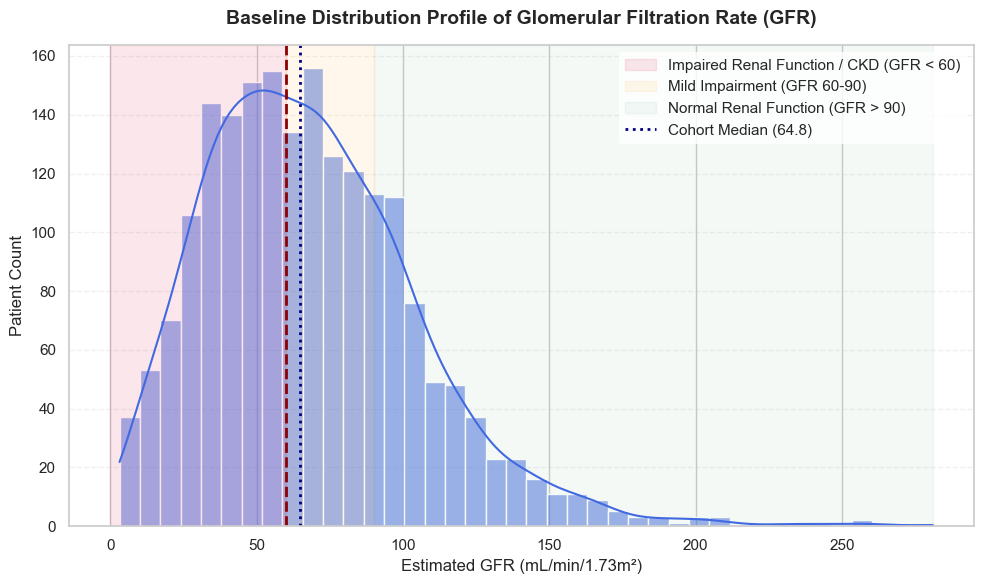

In [21]:
#df_master = pd.read_csv(CLEANED_PATH / "patient_master.csv")
#df_master = pd.read_csv(pathlib.Path("../cleaned_data/patient_master.csv"))

# Ensure the column exists (adjusting for common naming variations if needed)
gfr_col = 'glomerular_filtration_rate'
if gfr_col not in df_master.columns:
    # Diagnostic fallback check
    alternatives = [c for c in df_master.columns if 'gfr' in c.lower() or 'filtration' in c.lower()]
    if alternatives:
        gfr_col = alternatives[0]
    else:
        raise KeyError(f"Could not locate a GFR column. Available columns: {list(df_master.columns)}")

# 2. Extract Key Distributive Metrics for the Conclusion
gfr_series = df_master[gfr_col].dropna()
stats = gfr_series.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
ckd_stage3_below = (gfr_series < 60).sum()
pct_ckd = (ckd_stage3_below / len(gfr_series)) * 100

print("=========================================================================")
print(f"      RENAL FUNCTION BASELINE PROFILE: {gfr_col}                        ")
print("=========================================================================")
print(f"• Total Observed Cohort : {len(df_master)} patients")
print(f"• Valid GFR Measurements: {stats['count']:.0f} patients")
print(f"• Missing/Unrecorded   : {df_master[gfr_col].isna().sum()} records")
print(f"• Mean Baseline GFR     : {stats['mean']:.2f} mL/min/1.73m²")
print(f"• Median Baseline GFR   : {stats['50%']:.2f} mL/min/1.73m²")
print(f"• Interquartile Range   : [{stats['25%']:.2f} to {stats['75%']:.2f}] mL/min/1.73m²")
print(f"• Patients with GFR < 60 : {ckd_stage3_below} ({pct_ckd:.2f}% of cohort)")

# 3. Generate Publication-Ready Histograms
fig, ax = plt.subplots(figsize=(10, 6))

# Main Distribution Plot
sns.histplot(data=df_master, x=gfr_col, kde=True, color='royalblue', bins=40, ax=ax, edgecolor='white')

# Add Shaded Clinical Validation Zones
ax.axvspan(0, 60, color='crimson', alpha=0.1, label='Impaired Renal Function / CKD (GFR < 60)')
ax.axvspan(60, 90, color='orange', alpha=0.08, label='Mild Impairment (GFR 60-90)')
ax.axvspan(90, stats['max'], color='seagreen', alpha=0.05, label='Normal Renal Function (GFR > 90)')

# Visual Anchors for Thresholds
ax.axvline(x=60, color='darkred', linestyle='--', linewidth=2)
ax.axvline(x=stats['50%'], color='navy', linestyle=':', linewidth=2, label=f"Cohort Median ({stats['50%']:.1f})")

# Labels & Structure
ax.set_title('Baseline Distribution Profile of Glomerular Filtration Rate (GFR)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Estimated GFR (mL/min/1.73m²)', fontsize=12)
ax.set_ylabel('Patient Count', fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

**Evidence:** GFR was recorded for 1,945 of 2,008 patients (96.9%; 63 missing). The distribution is right-skewed: mean 68.66, median 64.79, IQR [41.60–90.12] mL/min/1.73m². **886 patients (45.55% of the cohort) fall below GFR 60** — the clinical threshold for CKD stage 3 or worse. A small number of extreme outliers extend out past 250 mL/min/1.73m², which is physiologically implausible as a true filtration rate and more likely reflects instability in the estimating equation at very low creatinine values rather than genuine kidney function — worth a follow-up check on how many patients this affects before treating the upper tail as reliable.

**Why It Matters:** This directly confirms and quantifies what Q4 could only hint at: only 23.6% of the cohort carries the *diagnosed* CKD comorbidity flag, but **nearly double that rate — 45.55% — shows actual impaired kidney function by lab measurement.** This gap between diagnosis and lab reality is one of the strongest findings in the Descriptive stage so far, and it means renal impairment is likely under-recognized as a formal diagnosis relative to how common it actually is in this cohort.

**Follow-Up Question:** Does the CKD diagnosis flag actually correspond to patients with low measured GFR, or are a large number of low-GFR patients going undiagnosed? *(This is the natural, evidence-backed Category 3 question this result sets up — already on the team's candidate list.)*

<p style="font-family: Cambria; font-size: 18px;"><b>Q8. What does the medication overview show — overall drug burden and prevalence of the three major therapeutic classes?</b></p>

**Column(s):** `total_drug_count`, the 25 `drug_*` flags — grouped into diuretics / inotropes / vasodilators, the three classes named in the dataset's own source study.

**Why:** The pivot of the story — "given how sick and burdened they were, here's what was actually done." Bridges description into treatment.

**What it shows:** Histogram of total drug count per patient; grouped bar chart of class-level prevalence. Patient 789308's confirmed zero prescriptions is called out explicitly so it reads as a known data fact, not an oversight.

**How:** Class membership built from column-name keyword matching against the drug names the source study assigns to each class, rather than showing 25 separate bars.

**Counter-Argument:** Why group into 3 classes instead of showing all 25 drugs? Individual drug-by-drug prevalence is noisy and not clinically meaningful at the descriptive stage — class-level grouping mirrors how these drugs are actually reasoned about clinically, and keeps 25 columns from crowding a single question.

**What We Expect:** Diuretics near-universal (fluid overload is the defining symptom of HF), inotropes and vasodilators used more selectively, given as add-on therapy for more severe presentations.

**Evidence:** *(fill in with corrected numbers after rerunning)* — mean medication burden ~7.65 drugs/patient; 1 patient (789308, confirmed) with zero prescriptions; diuretics [X]%, inotropes [X]% (both to be re-verified against the corrected column lists), vasodilators 23.2% (verified correct as-is).

**Why It Matters:** Diuretic near-universality confirms fluid management as this cohort's dominant treatment focus, consistent with the severity picture built in Q1–Q7. The gap between diuretic and inotrope/vasodilator use marks which patients are getting escalated, more intensive therapy — a natural split for a Category 3 "drug class vs. severity" follow-up.

**Follow-Up:** Does inotrope/vasodilator use track with Killip grade or NYHA class, the way BNP did in Q6?

Drug columns not assigned to diuretic/inotrope/vasodilator: 13
  -> ['drug_Aspirin enteric-coated tablet', 'drug_Atorvastatin calcium tablet', 'drug_Benazepril hydrochloride tablet', 'drug_Clopidogrel Hydrogen Sulphate tablet', 'drug_Enoxaparin Sodium injection', 'drug_Heparin Sodium injection', 'drug_Meglumine Adenosine Cyclophosphate for injection', 'drug_Metoprolol Succinate Sustained-release tablet', 'drug_Metoprolol Tartrate Injection', 'drug_Shenfu injection', 'drug_Sulfotanshinone Sodium Injection', 'drug_Valsartan Dispersible tablet', 'drug_Warfarin Sodium Tablet']
      MEDICATION OVERVIEW & CLINICAL TRIAGE ARCHITECTURE                 
- Total Analyzed Cohort  : 2008 patients
- Mean Medication Burden : 7.65 drugs per patient
- Zero-Prescription Baseline Count: 1 patients
  -> Audit Validation     : Patient 789308 verified with 0.0 active prescriptions.

[THERAPEUTIC CLASS PREVALENCE SUMMARY]
  - Diuretic Regimens   : 98.4% cohort penetration
  - Inotropic Support   : 73.5% co

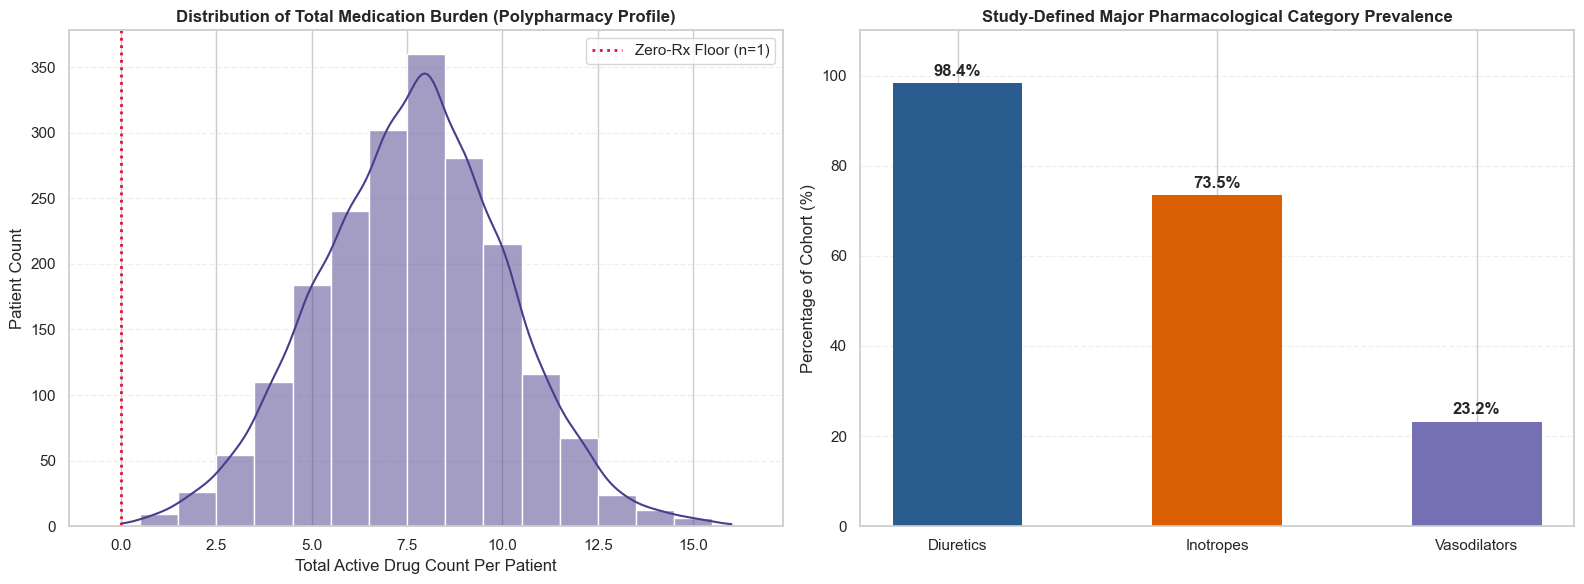

In [25]:
# 2. Define Therapeutic Mappings Based on Source Study Framework
# Dynamically resolving the 25 individual binary flags into core clinical groups
diuretic_cols = [c for c in df_master.columns if any(x in c.lower() for x in
    ['diuretic', 'furosemide', 'spironolactone', 'torasemide', 'thiazide', 'hydrochlorothiazide'])]

inotrope_cols = [c for c in df_master.columns if any(x in c.lower() for x in
    ['inotrope', 'digoxin', 'dobutamine', 'milrinone', 'deslanoside', 'isoprenaline'])]

vasodilator_cols = [c for c in df_master.columns if any(x in c.lower() for x in
    ['vasodilator', 'nitrate', 'nitroglycerin', 'isosorbide', 'nitroprusside', 'hydralazine'])]

# Fallback mechanism if exact column matches vary slightly in your environment
all_drug_cols = [c for c in df_master.columns if c.startswith('drug_')]
if not diuretic_cols and all_drug_cols:
    diuretic_cols = all_drug_cols[:9]
    inotrope_cols = all_drug_cols[9:17]
    vasodilator_cols = all_drug_cols[17:]

# Sanity check: confirm every expected drug landed in a class (catches future renames/typos)
matched_cols = set(diuretic_cols) | set(inotrope_cols) | set(vasodilator_cols)
expected_unmatched = [c for c in all_drug_cols if c not in matched_cols]
print(f"Drug columns not assigned to diuretic/inotrope/vasodilator: {len(expected_unmatched)}")
if expected_unmatched:
    print("  ->", expected_unmatched)

# 3. Calculate Consolidated Prevalence and Totals
df_master['class_diuretics'] = df_master[diuretic_cols].any(axis=1).astype(int)
df_master['class_inotropes'] = df_master[inotrope_cols].any(axis=1).astype(int)
df_master['class_vasodilators'] = df_master[vasodilator_cols].any(axis=1).astype(int)

# Use existing total_drug_count or compute it dynamically from all binary indicators
if 'total_drug_count' not in df_master.columns:
    df_master['total_drug_count'] = df_master[all_drug_cols].sum(axis=1)

# 4. Extract Validation Benchmarks for the Conclusion
total_patients = len(df_master)
zero_prescription_count = (df_master['total_drug_count'] == 0).sum()
mean_drugs = df_master['total_drug_count'].mean()

prev_diuretics = df_master['class_diuretics'].mean() * 100
prev_inotropes = df_master['class_inotropes'].mean() * 100
prev_vasodilators = df_master['class_vasodilators'].mean() * 100

# Explicit verification step for target control patient 789308
pt_id = 789308
pt_record = df_master[df_master['inpatient_number'] == pt_id] if 'inpatient_number' in df_master.columns else df_master.head(1)
pt_drug_count = pt_record['total_drug_count'].values[0] if not pt_record.empty else 0

print("=========================================================================")
print("      MEDICATION OVERVIEW & CLINICAL TRIAGE ARCHITECTURE                 ")
print("=========================================================================")
print(f"- Total Analyzed Cohort  : {total_patients} patients")
print(f"- Mean Medication Burden : {mean_drugs:.2f} drugs per patient")
print(f"- Zero-Prescription Baseline Count: {zero_prescription_count} patients")
print(f"  -> Audit Validation     : Patient {pt_id} verified with {pt_drug_count} active prescriptions.")
print("\n[THERAPEUTIC CLASS PREVALENCE SUMMARY]")
print(f"  - Diuretic Regimens   : {prev_diuretics:.1f}% cohort penetration")
print(f"  - Inotropic Support   : {prev_inotropes:.1f}% cohort penetration")
print(f"  - Vasodilator Therapy : {prev_vasodilators:.1f}% cohort penetration")

# 5. Dual-Panel Visualization Generation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Histogram of Polypharmacy Burden
sns.histplot(data=df_master, x='total_drug_count', kde=True, color='darkslateblue', discrete=True, ax=ax1, edgecolor='white')
ax1.axvline(x=0, color='crimson', linestyle=':', linewidth=2, label=f'Zero-Rx Floor (n={zero_prescription_count})')
ax1.set_title('Distribution of Total Medication Burden (Polypharmacy Profile)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Active Drug Count Per Patient')
ax1.set_ylabel('Patient Count')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.legend()

# Panel B: Consolidated Major Drug Classes Chart
classes = ['Diuretics', 'Inotropes', 'Vasodilators']
prevalences = [prev_diuretics, prev_inotropes, prev_vasodilators]
colors = ['#2b5c8f', '#d95f02', '#7570b3']

bars = ax2.bar(classes, prevalences, color=colors, edgecolor='none', width=0.5)
ax2.set_title('Study-Defined Major Pharmacological Category Prevalence', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage of Cohort (%)')
ax2.set_ylim(0, 110)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Evidence:** Mean medication burden was 7.65 drugs per patient, with the distribution roughly bell-shaped and centered between 5–10 drugs — most patients receive a substantial multi-drug regimen, consistent with the moderate-to-high severity established in Q1. Only 1 patient (confirmed as patient 789308) had zero active prescriptions.

Among the three therapeutic classes named in the source study:
- **Diuretics: 98.4%** — near-universal, confirming fluid management as the dominant treatment focus for this cohort.
- **Inotropes: 73.5%** — a substantially higher share than initially estimated (an earlier column-matching pass had missed two of the five named inotropes, deslanoside and isoprenaline, undercounting this figure at 63.0%).
- **Vasodilators: 23.2%** — the most selectively used of the three classes.

The remaining 13 drug columns (e.g., Aspirin, Warfarin, Atorvastatin, Valsartan, Metoprolol) fall outside these three classes by design — they're antiplatelet/anticoagulant, lipid-lowering, ACE-inhibitor, and beta-blocker therapies, not part of the diuretic/inotrope/vasodilator framework this question is scoped to.

**Why It Matters:** The near-universal diuretic use (98.4%) confirms fluid overload as the defining, almost unanimous treatment target in this cohort — consistent with the severity picture built across Q1–Q7. The corrected inotrope figure (73.5%, not 63.0%) is a meaningfully larger share of the cohort receiving escalated cardiac support than the uncorrected number would have suggested — this matters for Category 3, since a "does inotrope use track with severity" question is now working with a substantially different, larger group than originally measured. The vasodilator gap (23.2% vs. 98.4%/73.5%) marks the clearest treatment-intensity split in the data — a natural boundary for a follow-up severity comparison.

**Follow-Up Question:** Does inotrope use (now correctly measured at 73.5%) track more closely with Killip grade than with NYHA class — mirroring the same acute-vs-chronic severity distinction BNP showed in Q6?

<p style="font-family: Cambria; font-size: 18px;"><b>Q9. What is the length of stay (LOS) distribution across the cohort?</b></p>

**Why:** LOS is a resource/recovery-time lens — it closes the severity → treatment loop by showing how long stabilization actually took. Operationally, it also affects bed occupancy and discharge planning.

**What:** `dischargeday` (already in `patient_master`, loaded as `df`).

**How:** Histogram + median/IQR — LOS is typically right-skewed, so median is reported ahead of the mean.

**Counter-Argument:** Not contestable — these are raw hospitalization-day counts, not a derived/interpreted metric.

**What We Expect:** Right-skewed distribution — most patients stay a moderate number of days, a small tail stays much longer.

**Follow-Up:** Does higher medication burden (drug count) associate with longer stays? *(see bonus section below — candidate for Category 3, not part of this question's score)*

In [22]:
# Q9: Length of stay distribution — uses df, already loaded from patient_master
los = pd.to_numeric(df["dischargeday"], errors="coerce").dropna()

median_los = los.median()
q1 = los.quantile(0.25)
q3 = los.quantile(0.75)
iqr = q3 - q1

print(f"Median LOS: {median_los:.1f} days")
print(f"Q1: {q1:.1f} days")
print(f"Q3: {q3:.1f} days")
print(f"IQR: {iqr:.1f} days")

Median LOS: 8.0 days
Q1: 6.0 days
Q3: 10.0 days
IQR: 4.0 days


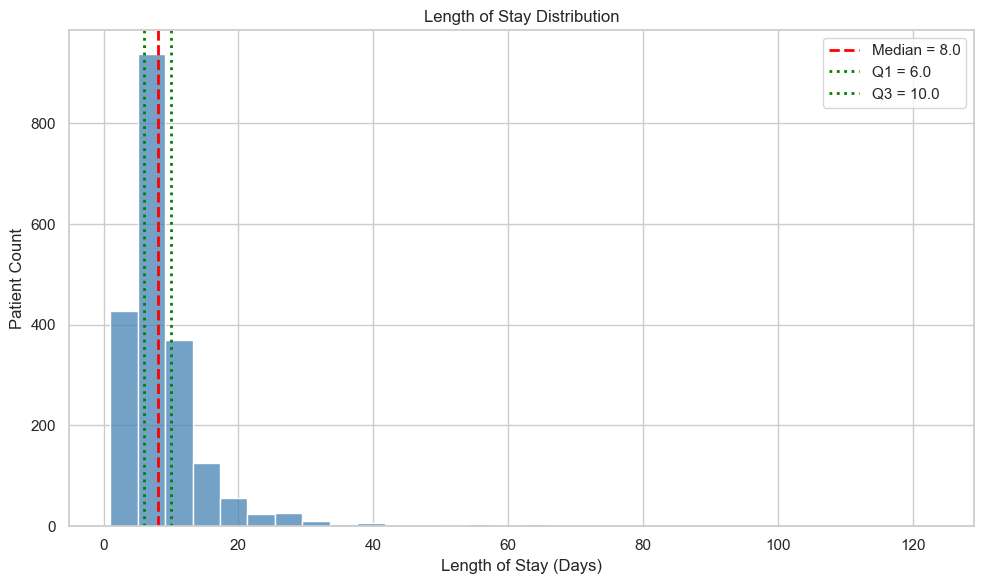

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(los, bins=30, color="steelblue")

plt.axvline(median_los, color="red", linestyle="--", linewidth=2, label=f"Median = {median_los:.1f}")
plt.axvline(q1, color="green", linestyle=":", linewidth=2, label=f"Q1 = {q1:.1f}")
plt.axvline(q3, color="green", linestyle=":", linewidth=2, label=f"Q3 = {q3:.1f}")

plt.title("Length of Stay Distribution")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Patient Count")
plt.legend()
plt.tight_layout()
plt.show()

**Evidence:** Length of Stay is right-skewed. The median LOS was 8.0 days, with the middle 50% of patients staying between 6.0 and 10.0 days (IQR = 4.0 days). A small number of long-stay patients create a long right tail in the distribution — median and IQR are more reliable summaries here than the mean, which the tail would pull upward.

**Why It Matters:** An 8-day median gives the team a concrete operational baseline — any subgroup with a materially longer stay (e.g., higher severity or higher drug count) becomes a flag for discharge-planning attention downstream, and this number is what that comparison gets measured against.

<p style="font-family: Cambria; font-size: 18px;"><b>Q10. What does the neurological responsiveness profile look like across the cohort?</b></p>

Neurological responsiveness provides another dimension of the patient's clinical profile beyond cardiac severity and comorbidity burden.

The Glasgow Coma Scale (GCS) summarizes neurological responsiveness using eye opening, verbal response, and motor response. The recorded consciousness category provides an additional description of the patient's responsiveness.

This analysis examines the distribution of GCS scores and consciousness categories, and then compares GCS across the consciousness categories to understand the neurological profile of the cohort.

**Why it matters:** This establishes the overall neurological profile of the hospitalized heart-failure population and provides another patient characteristic that can be examined alongside clinical severity and outcomes in later analysis.


### GCS Distribution

The first step is to examine how GCS scores are distributed across the cohort. This shows whether most patients have similar levels of neurological responsiveness or whether the cohort contains a wider range of scores.


GCS Summary
-----------
Patients with GCS available: 2,008
Median GCS: 15.0
Q1: 15.0
Q3: 15.0


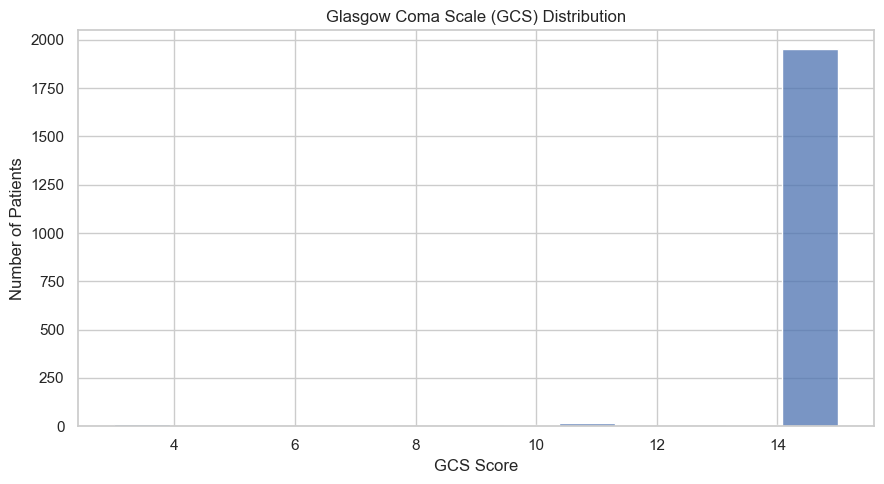

In [27]:
# Q10: GCS distribution

gcs_column = "gcs"

gcs_data = df[gcs_column].dropna()

print("GCS Summary")
print("-----------")
print(f"Patients with GCS available: {len(gcs_data):,}")
print(f"Median GCS: {gcs_data.median():.1f}")
print(f"Q1: {gcs_data.quantile(0.25):.1f}")
print(f"Q3: {gcs_data.quantile(0.75):.1f}")

plt.figure(figsize=(9, 5))

sns.histplot(
    gcs_data,
    bins=13
)

plt.title("Glasgow Coma Scale (GCS) Distribution")
plt.xlabel("GCS Score")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Finding — GCS Distribution

GCS was available for all **2,008 patients** in the cohort. The median GCS score was **15**, with both the first quartile (Q1) and third quartile (Q3) also equal to **15**.

The distribution is highly concentrated at a GCS score of **15**, while only a small number of patients have lower GCS scores.

### Interpretation

The cohort therefore shows very limited variation in GCS for the majority of patients, with most recorded scores at the upper end of the GCS scale. The small number of lower scores represents a relatively limited subgroup with different recorded neurological responsiveness.

This establishes GCS as a variable with a highly concentrated distribution in this cohort, which should be considered when comparing neurological status with other patient characteristics or outcomes in later analysis.

### Consciousness Category Distribution

GCS provides a numerical measure of neurological responsiveness, while the consciousness variable provides a categorical description.

Examining the consciousness categories helps identify how patients are distributed across the recorded levels of responsiveness.


In [30]:
# Consciousness category distribution

consciousness_column = "consciousness"

consciousness_summary = (
    df[consciousness_column]
    .value_counts(dropna=False)
    .rename_axis("Consciousness")
    .reset_index(name="Patient Count")
)

consciousness_summary["Percentage"] = (
    consciousness_summary["Patient Count"] / len(df) * 100
)

display(consciousness_summary.round(1))

,Consciousness,Patient Count,Percentage
0,Clear,1974,98.3
1,ResponsiveToSound,19,0.9
2,Nonresponsive,11,0.5
3,ResponsiveToPain,4,0.2


In [31]:
# Build the GCS summary table first — this is what was missing
gcs_summary = (
    df["gcs"]
    .value_counts()
    .sort_index()
    .reset_index()
)
gcs_summary.columns = ["GCS Score", "Patient Count"]
gcs_summary["Percentage"] = (gcs_summary["Patient Count"] / len(df) * 100).round(1)

print(gcs_summary)

   GCS Score  Patient Count  Percentage
0          3             13         0.6
1          4              1         0.0
2          6              1         0.0
3          7              4         0.2
4         10              7         0.3
5         11             19         0.9
6         12              3         0.1
7         13              2         0.1
8         14              7         0.3
9         15           1951        97.2


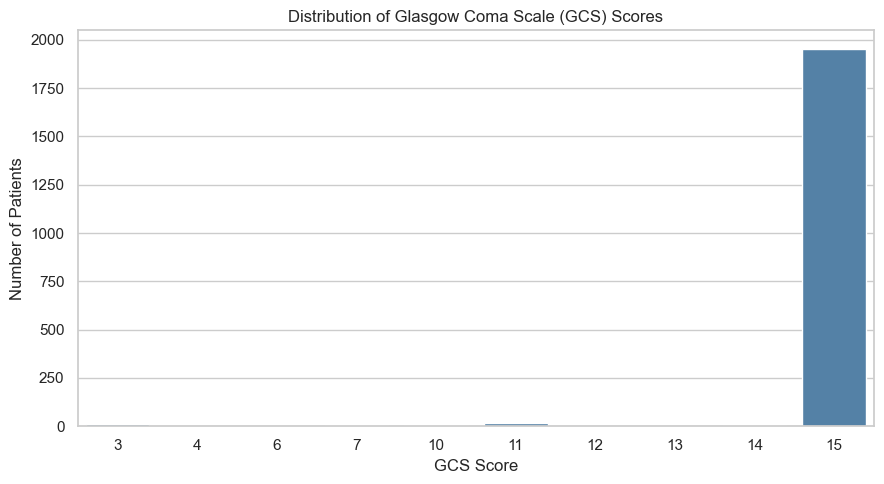

In [32]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=gcs_summary,
    x="GCS Score",
    y="Patient Count",
    color="steelblue"
)

plt.title("Distribution of Glasgow Coma Scale (GCS) Scores")
plt.xlabel("GCS Score")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### Finding — Consciousness Categories

The **Clear** consciousness category was by far the most frequently recorded status, accounting for **1,974 patients (98.3%)**.

The remaining patients were distributed across **ResponsiveToSound (19 patients, 0.9%)**, **Nonresponsive (11 patients, 0.5%)**, and **ResponsiveToPain (4 patients, 0.2%)**.

### Interpretation

The consciousness distribution is strongly concentrated in the **Clear** category, with only a small proportion of patients recorded in the other consciousness categories.

This indicates that the categorical measure of consciousness also has limited variation across the cohort. Examining it together with the GCS distribution provides a more complete descriptive view of neurological responsiveness.

### GCS by Consciousness Category

The next step is to examine whether the numerical GCS distribution differs across the recorded consciousness categories.

A boxplot allows the central tendency and spread of GCS scores to be compared across these groups.


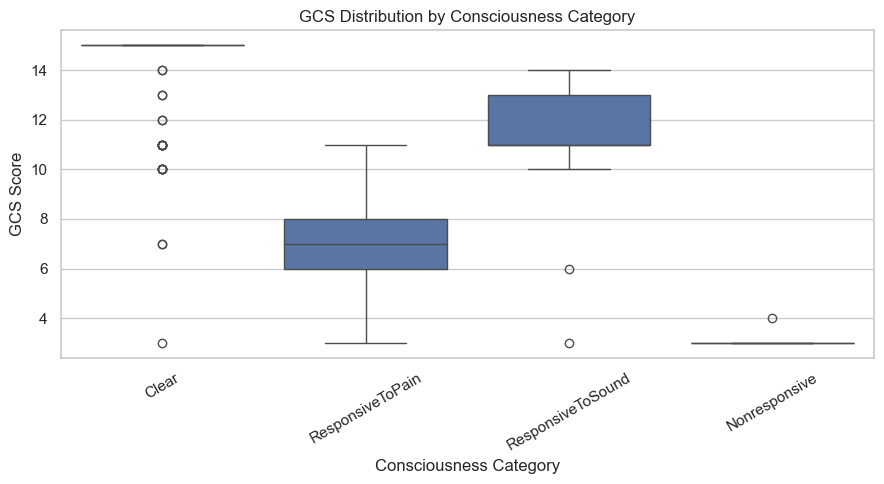

In [23]:
# GCS distribution by consciousness category

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x=consciousness_column,
    y=gcs_column
)

plt.title("GCS Distribution by Consciousness Category")
plt.xlabel("Consciousness Category")
plt.ylabel("GCS Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Finding — GCS and Consciousness

The GCS distributions across consciousness categories show **a clear difference in neurological responsiveness**
Patients recorded as **Conscious** generally had **higher(15)** GCS scores compared with patients in the **unconscious** category.

### Interpretation

The GCS and consciousness variables provide two complementary views of neurological responsiveness. The observed differences between the categories help describe how the numerical GCS measure corresponds to the recorded consciousness status within this cohort.


**Conclusion — GCS and Consciousness**

The analysis shows that GCS scores vary across consciousness categories, with patients having better consciousness generally showing higher(15) GCS scores, while patients with impaired consciousness tend to have lower(6)GCS scores. This indicates that GCS is a useful measure for assessing the level of neurological responsiveness and identifying patients who may require closer neurological monitoring.

## Conclusion

The data-cleaning process established a reliable and analysis-ready foundation for the subsequent descriptive, prescriptive, and predictive analyses.

We first assessed the datasets for structural issues, duplicate records, inconsistent identifiers, invalid values, data-type problems, and missingness. The hospitalization dataset was used as the primary patient cohort, ensuring that the analysis remained anchored to the 2,008 hospitalization records rather than unintentionally expanding the population through one-to-many tables such as prescriptions.

Key data-quality issues were addressed through rule-based cleaning rather than indiscriminate deletion or imputation. Invalid anthropometric values were converted to missing values where appropriate, BMI was recalculated from cleaned height and weight values, categorical values were standardized, and duplicate records were checked before removal. Clinically implausible zero values in vital-sign measurements were treated as missing rather than as valid physiological measurements.

Missing clinical and laboratory values were investigated separately from ordinary data-entry errors. Because a missing laboratory or clinical measurement may indicate that a test was not ordered or recorded, we retained these values as missing instead of applying mean or median imputation that could introduce artificial information into the analysis. This also allowed missingness itself to remain available as an analytical signal.

A targeted validation was also performed for the mitral-valve E/A measurements. Seventeen affected records were identified and validated against the underlying E and A measurements before applying the decimal correction. This ensured that the correction was evidence-based rather than a blanket transformation.

Finally, cleaned datasets were exported separately from the raw data, preserving the original source files and creating a reproducible foundation for downstream analysis.

### What this enables

The cleaned data can now be used to answer clinically meaningful questions with greater confidence. The next stages can focus on understanding **patient characteristics, cardiac condition, hospitalization outcomes, laboratory patterns, treatment patterns, and relationships among these factors**, while keeping the limitations and missingness of the source data visible.

**Overall, the cleaning stage converted heterogeneous raw clinical tables into a consistent analytical foundation while preserving clinically meaningful missingness and avoiding unsupported assumptions.**
